
# Data Mining, Modelling and Analytics Exam

**Selected domain:** Climate Change: Predicting Extreme Events

**Objective:** Predict whether a given day is an **extreme rainfall day** using historical meteorological variables and engineered temporal/climate features.

**Full names:** Barbra Ebal Apilli

**Access number:** B35496


In [1]:

# Core libraries
import os
import re
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

import joblib

# Optional
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except Exception:
    WORDCLOUD_AVAILABLE = False

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)



## Part A.1 — Problem framing

### Problem statement
Extreme weather events create material risks for climate adaptation, agriculture, water-resource planning, transport, and disaster preparedness.  
In this project, the decision problem is:

> **Can we predict whether a day will be an extreme rainfall day using daily meteorological observations and engineered temporal features?**

### Decision objective
Support climate-risk awareness by classifying each day as:
- **1 = Extreme rainfall day**
- **0 = Non-extreme rainfall day**

### Candidate predictors
- Daily maximum temperature
- Daily minimum temperature
- Daily mean temperature
- Maximum wind speed
- Surface pressure
- Maximum relative humidity
- Temporal variables: month, quarter, day of year, seasonality indicators
- Lagged/rolling weather dynamics

### Target variable
`extreme_rain_event` derived from precipitation totals using a percentile-based threshold.


In [2]:

# File path for the uploaded Open-Meteo dataset
raw_file = "open-meteo-1.23N32.53E1090m.csv"

# The file contains metadata rows first, then the actual table.
# We parse it carefully rather than using a single direct read_csv call.
with open(raw_file, "r", encoding="utf-8") as f:
    raw_lines = [line.strip() for line in f.readlines()]

# Extract metadata (first two non-empty lines)
metadata_header = raw_lines[0].split(",")
metadata_values = raw_lines[1].split(",")
metadata = dict(zip(metadata_header, metadata_values))

# Find the actual data header row (starts with 'time,')
data_header_idx = next(i for i, line in enumerate(raw_lines) if line.startswith("time,"))
data_lines = raw_lines[data_header_idx:]

from io import StringIO
weather = pd.read_csv(StringIO("\n".join(data_lines)))

print("Metadata:")
print(metadata)
print("\nDataset shape:", weather.shape)
weather.head()


Metadata:
{'latitude': '1.2302284', 'longitude': '32.533543', 'elevation': '1090.0', 'utc_offset_seconds': '10800', 'timezone': 'Africa/Kampala', 'timezone_abbreviation': 'GMT+3'}

Dataset shape: (3653, 8)


,time,temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm),temperature_2m_mean (°C),wind_speed_10m_max (km/h),surface_pressure_mean (hPa),relative_humidity_2m_max (%)
0,2015-01-01,30.6,19.4,0.0,25.1,12.5,893.1,73
1,2015-01-02,31.9,18.3,0.0,25.0,15.4,892.7,96
2,2015-01-03,32.4,17.5,0.0,25.0,10.1,893.1,78
3,2015-01-04,31.9,17.0,0.0,24.7,13.9,893.6,70
4,2015-01-05,31.2,18.7,0.0,25.3,16.6,893.4,78



## Part A.2 — Dataset description

The dataset contains daily weather observations from **2015-01-01 to 2024-12-31**.  
Each row represents one day and includes temperature, precipitation, wind speed, pressure, and humidity indicators.

This is suitable for predictive modeling because:
1. The data is **structured and time-indexed**.
2. It contains a direct climate outcome (`precipitation_sum`) from which an extreme-event target can be defined.
3. It supports feature engineering using temporal trends, lags, and rolling aggregates.


In [3]:

# Standardize column names
weather.columns = [
    "date",
    "temp_max_c",
    "temp_min_c",
    "precipitation_mm",
    "temp_mean_c",
    "wind_speed_max_kmh",
    "surface_pressure_hpa",
    "relative_humidity_max_pct"
]

# Convert data types
weather["date"] = pd.to_datetime(weather["date"], errors="coerce")
numeric_cols = [c for c in weather.columns if c != "date"]
for c in numeric_cols:
    weather[c] = pd.to_numeric(weather[c], errors="coerce")

# Initial quality checks
print("Missing values before cleaning:")
display(weather.isna().sum())

print("\nDuplicate rows:", weather.duplicated().sum())

# Sort by date and drop duplicates if any
weather = weather.sort_values("date").drop_duplicates().reset_index(drop=True)

# Handle missing values with time-aware interpolation for numeric columns
weather[numeric_cols] = weather[numeric_cols].interpolate(method="linear", limit_direction="both")

# Clip impossible lower bounds where appropriate
weather["precipitation_mm"] = weather["precipitation_mm"].clip(lower=0)
weather["relative_humidity_max_pct"] = weather["relative_humidity_max_pct"].clip(lower=0, upper=100)
weather["wind_speed_max_kmh"] = weather["wind_speed_max_kmh"].clip(lower=0)

# Outlier capping using IQR for selected continuous features
def cap_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series.clip(lower, upper)

for col in [
    "temp_max_c", "temp_min_c", "temp_mean_c",
    "precipitation_mm", "wind_speed_max_kmh",
    "surface_pressure_hpa", "relative_humidity_max_pct"
]:
    weather[col] = cap_iqr(weather[col])

print("Missing values after cleaning:")
display(weather.isna().sum())

weather.describe(include="all").T


Missing values before cleaning:


date                         0
temp_max_c                   0
temp_min_c                   0
precipitation_mm             0
temp_mean_c                  0
wind_speed_max_kmh           0
surface_pressure_hpa         0
relative_humidity_max_pct    0
dtype: int64


Duplicate rows: 0
Missing values after cleaning:


date                         0
temp_max_c                   0
temp_min_c                   0
precipitation_mm             0
temp_mean_c                  0
wind_speed_max_kmh           0
surface_pressure_hpa         0
relative_humidity_max_pct    0
dtype: int64

,count,mean,min,25%,50%,75%,max,std
date,3653,2020-01-01 00:00:00,2015-01-01 00:00:00,2017-07-02 00:00:00,2020-01-01 00:00:00,2022-07-02 00:00:00,2024-12-31 00:00:00,NaN
temp_max_c,3653.0,28.897345,22.0,27.1,28.6,30.5,35.6,2.438056
temp_min_c,3653.0,18.703422,15.9,18.0,18.6,19.4,21.5,1.141568
precipitation_mm,3653.0,2.755954,0.0,0.1,0.9,4.5,11.1,3.545656
temp_mean_c,3653.0,23.206816,19.4,22.0,22.9,24.2,27.5,1.613239
wind_speed_max_kmh,3653.0,11.981823,4.8,9.8,11.6,13.8,19.8,2.929853
surface_pressure_hpa,3653.0,894.066712,890.65,893.2,894.1,894.9,897.45,1.257204
relative_humidity_max_pct,3653.0,93.775801,80.5,91.0,95.0,98.0,100.0,5.564736



## Part A.3 — Data preparation and saving cleaned dataset


In [4]:

# Temporal features
weather["year"] = weather["date"].dt.year
weather["month"] = weather["date"].dt.month
weather["day"] = weather["date"].dt.day
weather["day_of_year"] = weather["date"].dt.dayofyear
weather["week_of_year"] = weather["date"].dt.isocalendar().week.astype(int)
weather["quarter"] = weather["date"].dt.quarter

# Cyclical encoding
weather["month_sin"] = np.sin(2 * np.pi * weather["month"] / 12)
weather["month_cos"] = np.cos(2 * np.pi * weather["month"] / 12)
weather["dayofyear_sin"] = np.sin(2 * np.pi * weather["day_of_year"] / 365.25)
weather["dayofyear_cos"] = np.cos(2 * np.pi * weather["day_of_year"] / 365.25)

# Lag features
weather["precip_lag1"] = weather["precipitation_mm"].shift(1)
weather["precip_lag3"] = weather["precipitation_mm"].shift(3)
weather["temp_mean_lag1"] = weather["temp_mean_c"].shift(1)
weather["humidity_lag1"] = weather["relative_humidity_max_pct"].shift(1)
weather["wind_lag1"] = weather["wind_speed_max_kmh"].shift(1)

# Rolling features
weather["precip_roll3"] = weather["precipitation_mm"].rolling(3).mean()
weather["precip_roll7"] = weather["precipitation_mm"].rolling(7).mean()
weather["temp_roll3"] = weather["temp_mean_c"].rolling(3).mean()
weather["humidity_roll3"] = weather["relative_humidity_max_pct"].rolling(3).mean()

# Define extreme rainfall threshold (90th percentile)
rain_threshold = weather["precipitation_mm"].quantile(0.90)
weather["extreme_rain_event"] = (weather["precipitation_mm"] >= rain_threshold).astype(int)

# Drop initial NA rows caused by lag/rolling
model_df = weather.dropna().reset_index(drop=True)

print(f"Extreme rainfall threshold (90th percentile): {rain_threshold:.2f} mm")
print(model_df["extreme_rain_event"].value_counts(normalize=True).rename("proportion"))

# Save cleaned/transformed dataset
cleaned_filename = "Apilli.csv"
model_df.to_csv(cleaned_filename, index=False)
print(f"\nSaved cleaned dataset as: {cleaned_filename}")

model_df.head()


Extreme rainfall threshold (90th percentile): 9.20 mm
extreme_rain_event
0    0.898273
1    0.101727
Name: proportion, dtype: float64

Saved cleaned dataset as: Apilli.csv


,date,temp_max_c,temp_min_c,precipitation_mm,temp_mean_c,wind_speed_max_kmh,surface_pressure_hpa,relative_humidity_max_pct,year,month,day,day_of_year,week_of_year,quarter,month_sin,month_cos,dayofyear_sin,dayofyear_cos,precip_lag1,precip_lag3,temp_mean_lag1,humidity_lag1,wind_lag1,precip_roll3,precip_roll7,temp_roll3,humidity_roll3,extreme_rain_event
0,2015-01-07,31.2,18.3,0.0,25.5,15.7,894.5,80.5,2015,1,7,7,2,1,0.5,0.866025,0.120126,0.992759,0.0,0.0,25.6,80.5,16.8,0.0,0.0,25.466667,80.5,0
1,2015-01-08,30.7,20.0,0.0,25.4,16.3,894.5,80.5,2015,1,8,8,2,1,0.5,0.866025,0.137185,0.990545,0.0,0.0,25.5,80.5,15.7,0.0,0.0,25.500000,80.5,0
2,2015-01-09,30.4,20.2,0.0,25.3,17.1,894.8,80.5,2015,1,9,9,2,1,0.5,0.866025,0.154204,0.988039,0.0,0.0,25.4,80.5,16.3,0.0,0.0,25.400000,80.5,0
3,2015-01-10,30.4,20.3,0.0,25.1,15.6,894.9,80.5,2015,1,10,10,2,1,0.5,0.866025,0.171177,0.985240,0.0,0.0,25.3,80.5,17.1,0.0,0.0,25.266667,80.5,0
4,2015-01-11,29.9,19.9,0.0,24.5,19.8,894.7,80.5,2015,1,11,11,2,1,0.5,0.866025,0.188099,0.982150,0.0,0.0,25.1,80.5,15.6,0.0,0.0,24.966667,80.5,0


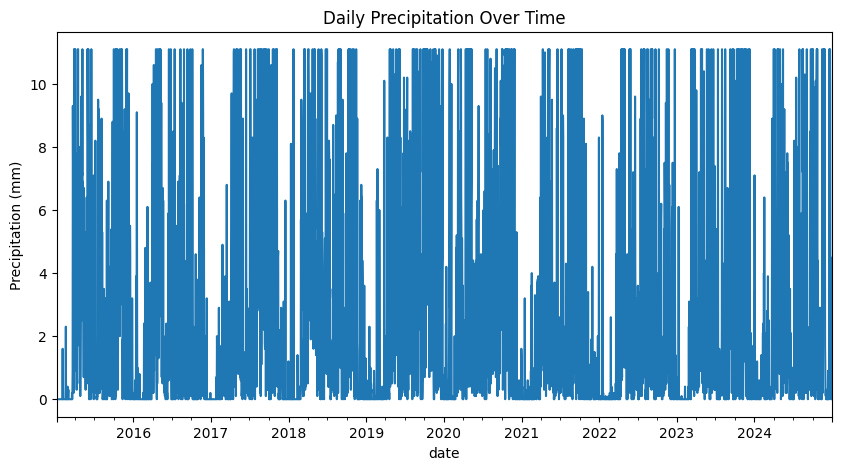

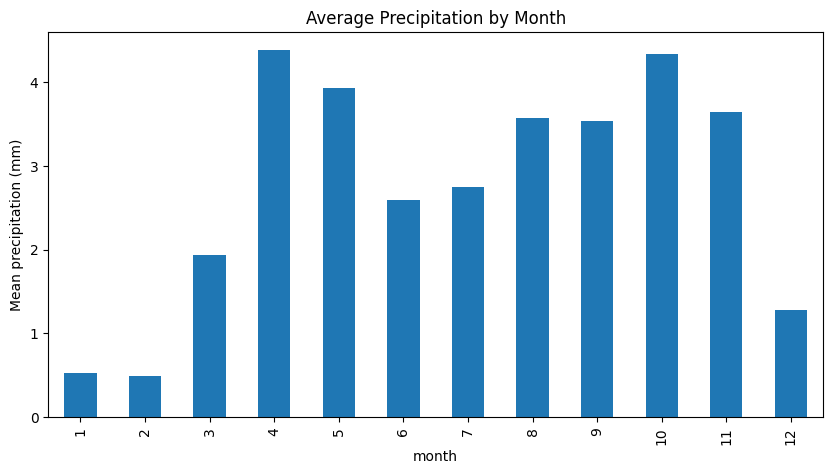

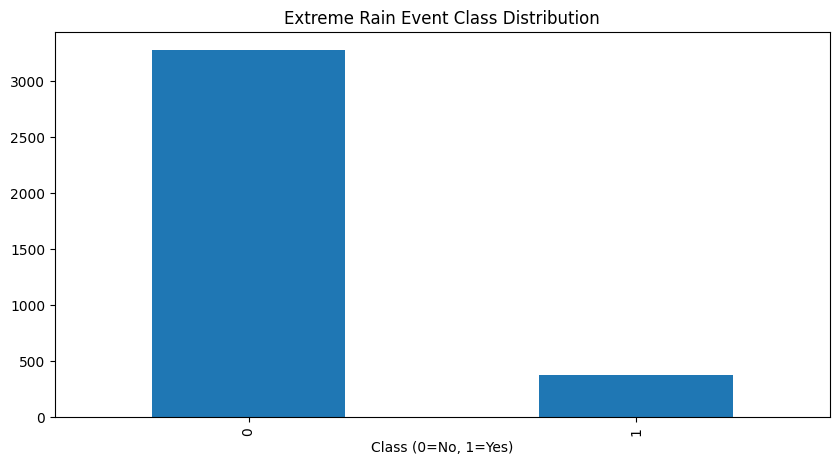

In [5]:

# Basic exploratory plots

fig, ax = plt.subplots()
model_df.set_index("date")["precipitation_mm"].plot(ax=ax)
ax.set_title("Daily Precipitation Over Time")
ax.set_ylabel("Precipitation (mm)")
plt.show()

fig, ax = plt.subplots()
model_df.groupby("month")["precipitation_mm"].mean().plot(kind="bar", ax=ax)
ax.set_title("Average Precipitation by Month")
ax.set_ylabel("Mean precipitation (mm)")
plt.show()

fig, ax = plt.subplots()
model_df["extreme_rain_event"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Extreme Rain Event Class Distribution")
ax.set_xlabel("Class (0=No, 1=Yes)")
plt.show()



## Part B.1 — Feature engineering and variable selection

### Selected features and justification
The selected features are relevant because extreme rainfall often depends on:
- **Humidity**: high humidity is strongly associated with rainfall potential
- **Temperature**: influences atmospheric convection and moisture dynamics
- **Wind speed**: can signal weather-system movement
- **Pressure**: low-pressure conditions often align with rainfall formation
- **Lag/rolling precipitation**: captures persistence and short-term weather memory
- **Seasonality variables**: rainfall regimes vary across months and seasons

We exclude the same-day raw precipitation from predictors because it directly defines the target.


In [6]:

# Feature set for prediction
feature_cols = [
    "temp_max_c", "temp_min_c", "temp_mean_c",
    "wind_speed_max_kmh", "surface_pressure_hpa", "relative_humidity_max_pct",
    "year", "month", "day", "day_of_year", "week_of_year", "quarter",
    "month_sin", "month_cos", "dayofyear_sin", "dayofyear_cos",
    "precip_lag1", "precip_lag3", "temp_mean_lag1", "humidity_lag1", "wind_lag1",
    "precip_roll3", "precip_roll7", "temp_roll3", "humidity_roll3"
]

target_col = "extreme_rain_event"

X = model_df[feature_cols]
y = model_df[target_col]

# Time-aware train-test split (no shuffling)
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
test_dates = model_df["date"].iloc[split_idx:]

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (2917, 25) Test size: (730, 25)


In [7]:

# Preprocessing
numeric_features = feature_cols

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

# Model 1: Logistic Regression
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

# Model 2: Random Forest
rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        random_state=42,
        class_weight="balanced"
    ))
])

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probas = model.predict_proba(X_test)[:, 1]

    result = {
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probas)
    }
    results.append(result)

results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
results_df


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.898630,0.513514,0.974359,0.672566,0.972176
1,Random Forest,0.913699,0.659574,0.397436,0.496000,0.947971


In [9]:

# Select best model using F1 score
best_model_name = results_df.loc[0, "model"]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

print("Best model:", best_model_name)

# Save best model
best_model_filename = "Apilli_best_model.joblib"
joblib.dump(best_model, best_model_filename)
print("Saved:", best_model_filename)

# Generate hold-out predictions
test_preds = best_model.predict(X_test)
test_probas = best_model.predict_proba(X_test)[:, 1]

predictions_df = pd.DataFrame({
    "date": test_dates.values,
    "actual": y_test.values,
    "predicted": test_preds,
    "prediction_probability": test_probas
})

predictions_filename = "predictions.csv"
predictions_df.to_csv(predictions_filename, index=False)
print("Saved:", predictions_filename)

predictions_df.head()


Best model: Logistic Regression
Saved: Apilli_best_model.joblib
Saved: predictions.csv


,date,actual,predicted,prediction_probability
0,2023-01-02,0,0,0.000060
1,2023-01-03,0,0,0.000329
2,2023-01-04,0,0,0.000028
3,2023-01-05,0,0,0.000038
4,2023-01-06,0,0,0.000340



## Part B.2–B.4 — Model comparison, prediction, and interpretation

The next cell prints:
- evaluation metrics,
- confusion matrix,
- classification report,
- interpretation notes.

Use this section in your report discussion for **sources of prediction error** and **practical implications**.


Model comparison:


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.898630,0.513514,0.974359,0.672566,0.972176
1,Random Forest,0.913699,0.659574,0.397436,0.496000,0.947971



Detailed report for: Logistic Regression
              precision    recall  f1-score   support

           0     0.9966    0.8896    0.9400       652
           1     0.5135    0.9744    0.6726        78

    accuracy                         0.8986       730
   macro avg     0.7550    0.9320    0.8063       730
weighted avg     0.9450    0.8986    0.9115       730



,Pred 0,Pred 1
Actual 0,580,72
Actual 1,2,76


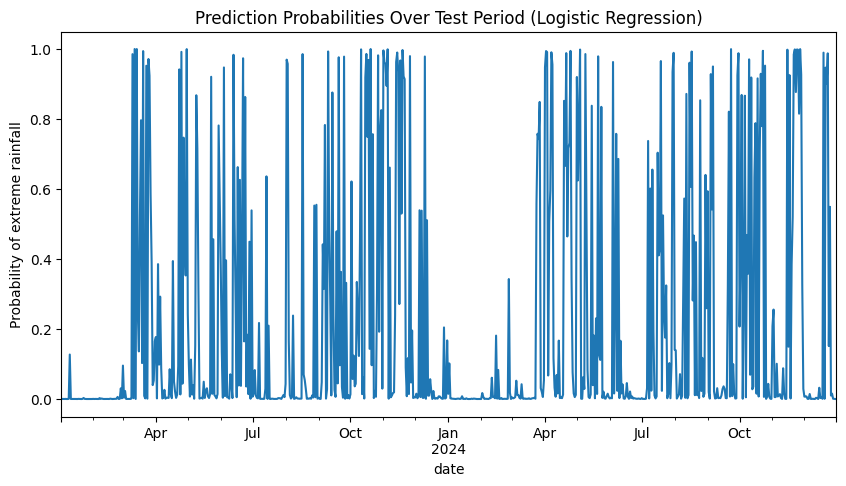

In [10]:

# Detailed evaluation of the best model
print("Model comparison:")
display(results_df)

print(f"\nDetailed report for: {best_model_name}")
print(classification_report(y_test, test_preds, digits=4))

cm = confusion_matrix(y_test, test_preds)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
display(cm_df)

fig, ax = plt.subplots()
predictions_df.set_index("date")["prediction_probability"].plot(ax=ax)
ax.set_title(f"Prediction Probabilities Over Test Period ({best_model_name})")
ax.set_ylabel("Probability of extreme rainfall")
plt.show()



## Part C.1 — Text mining / NLP component

To satisfy the exam requirement for a textual dataset, we **construct daily weather narratives** from the cleaned meteorological records.  
Example narrative:

> “On 2019-04-12, the day had very high humidity, moderate wind, warm temperatures, and heavy rainfall.”

This textual corpus is relevant because it translates structured weather signals into text descriptions that can be mined for patterns associated with extreme events.


In [11]:

def rain_label(mm):
    if mm == 0:
        return "no rainfall"
    elif mm < 5:
        return "light rainfall"
    elif mm < 20:
        return "moderate rainfall"
    else:
        return "heavy rainfall"

def humidity_label(h):
    if h < 50:
        return "low humidity"
    elif h < 75:
        return "moderate humidity"
    else:
        return "very high humidity"

def temp_label(t):
    if t < 20:
        return "cool temperatures"
    elif t < 27:
        return "warm temperatures"
    else:
        return "hot temperatures"

def wind_label(w):
    if w < 15:
        return "light wind"
    elif w < 30:
        return "moderate wind"
    else:
        return "strong wind"

text_df = model_df[[
    "date", "precipitation_mm", "relative_humidity_max_pct",
    "temp_mean_c", "wind_speed_max_kmh", "extreme_rain_event"
]].copy()

text_df["weather_text"] = text_df.apply(
    lambda r: (
        f"On {r['date'].date()}, the day recorded {rain_label(r['precipitation_mm'])}, "
        f"{humidity_label(r['relative_humidity_max_pct'])}, "
        f"{temp_label(r['temp_mean_c'])}, and {wind_label(r['wind_speed_max_kmh'])}."
    ),
    axis=1
)

text_df.head()


,date,precipitation_mm,relative_humidity_max_pct,temp_mean_c,wind_speed_max_kmh,extreme_rain_event,weather_text
0,2015-01-07,0.0,80.5,25.5,15.7,0,"On 2015-01-07, the day recorded no rainfall, v..."
1,2015-01-08,0.0,80.5,25.4,16.3,0,"On 2015-01-08, the day recorded no rainfall, v..."
2,2015-01-09,0.0,80.5,25.3,17.1,0,"On 2015-01-09, the day recorded no rainfall, v..."
3,2015-01-10,0.0,80.5,25.1,15.6,0,"On 2015-01-10, the day recorded no rainfall, v..."
4,2015-01-11,0.0,80.5,24.5,19.8,0,"On 2015-01-11, the day recorded no rainfall, v..."


,term,avg_tfidf
0,light,0.117196
1,warm,0.077646
2,warm temperatures,0.077646
3,humidity warm,0.077646
4,wind,0.077320
5,day,0.077320
6,recorded,0.077320
7,temperatures,0.077320
8,rainfall,0.077320
9,day recorded,0.077320


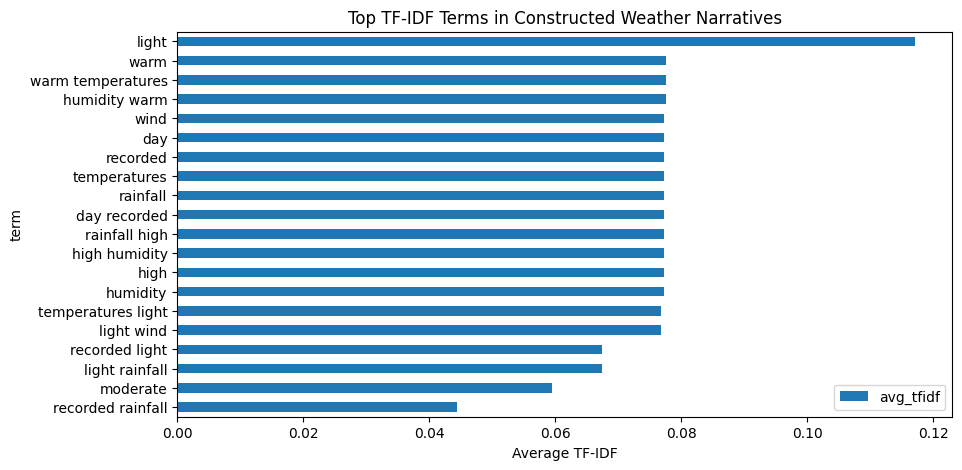

In [12]:

# NLP Task 1: TF-IDF keyword extraction
vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=5)
X_text = vectorizer.fit_transform(text_df["weather_text"])

feature_names = np.array(vectorizer.get_feature_names_out())
avg_tfidf = np.asarray(X_text.mean(axis=0)).ravel()
top_idx = avg_tfidf.argsort()[::-1][:20]

top_terms = pd.DataFrame({
    "term": feature_names[top_idx],
    "avg_tfidf": avg_tfidf[top_idx]
})

display(top_terms)

fig, ax = plt.subplots()
top_terms.iloc[::-1].plot(kind="barh", x="term", y="avg_tfidf", ax=ax)
ax.set_title("Top TF-IDF Terms in Constructed Weather Narratives")
ax.set_xlabel("Average TF-IDF")
plt.show()


,records,extreme_rate,avg_precip_mm
cluster,,,
1,790,0.436709,8.506709
2,609,0.042693,1.427915
0,2248,0.000000,1.102135


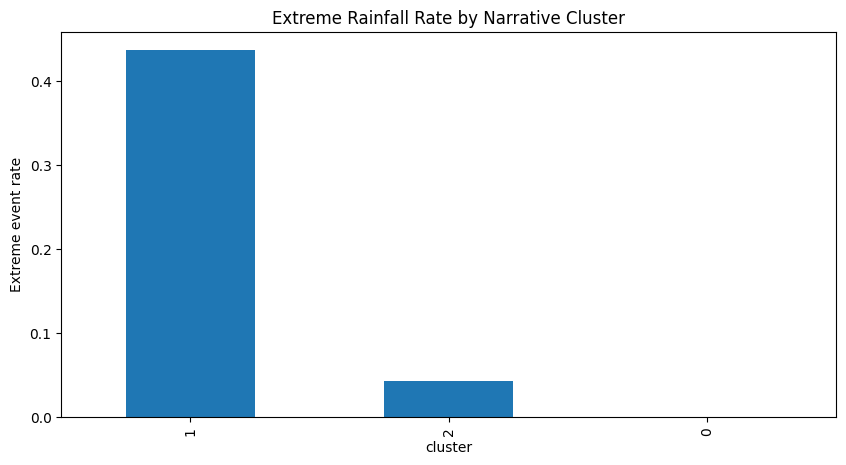

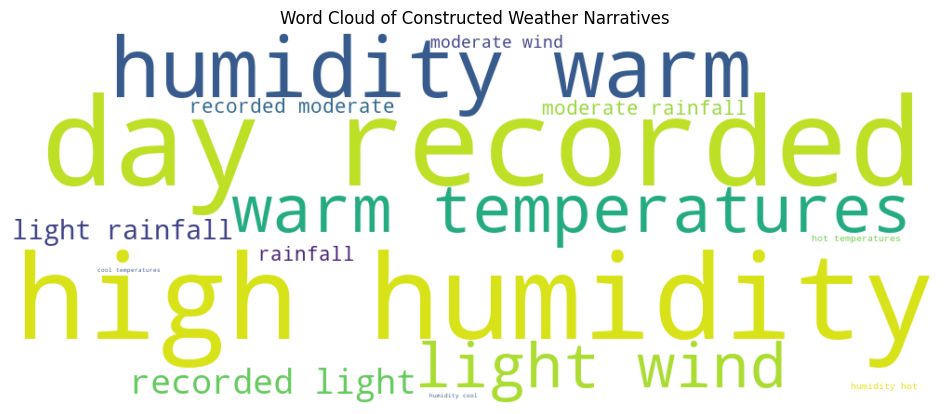

In [13]:

# NLP Task 2: Unsupervised clustering of weather narratives
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_text)
text_df["cluster"] = clusters

cluster_summary = text_df.groupby("cluster").agg(
    records=("weather_text", "count"),
    extreme_rate=("extreme_rain_event", "mean"),
    avg_precip_mm=("precipitation_mm", "mean")
).sort_values("extreme_rate", ascending=False)

display(cluster_summary)

fig, ax = plt.subplots()
cluster_summary["extreme_rate"].plot(kind="bar", ax=ax)
ax.set_title("Extreme Rainfall Rate by Narrative Cluster")
ax.set_ylabel("Extreme event rate")
plt.show()

if WORDCLOUD_AVAILABLE:
    all_text = " ".join(text_df["weather_text"].tolist())
    wc = WordCloud(width=1000, height=400, background_color="white").generate(all_text)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Constructed Weather Narratives")
    plt.show()
else:
    print("wordcloud package not available; TF-IDF chart already provides the required NLP visualization.")



## Part C.2 — Reuse of the saved predictive model

This section reloads the saved model and generates example inferences.


In [14]:

loaded_model = joblib.load("Apilli_best_model.joblib")

sample_inference = X_test.head(5).copy()
sample_probs = loaded_model.predict_proba(sample_inference)[:, 1]
sample_preds = loaded_model.predict(sample_inference)

inference_df = sample_inference.copy()
inference_df["predicted_extreme_event"] = sample_preds
inference_df["probability"] = sample_probs
inference_df


,temp_max_c,temp_min_c,temp_mean_c,wind_speed_max_kmh,surface_pressure_hpa,relative_humidity_max_pct,year,month,day,day_of_year,week_of_year,quarter,month_sin,month_cos,dayofyear_sin,dayofyear_cos,precip_lag1,precip_lag3,temp_mean_lag1,humidity_lag1,wind_lag1,precip_roll3,precip_roll7,temp_roll3,humidity_roll3,predicted_extreme_event,probability
2917,30.0,16.5,23.3,17.6,893.7,84.0,2023,1,2,2,1,1,0.5,0.866025,0.034398,0.999408,0.0,0.1,23.1,97.0,18.8,0.000000,0.128571,23.233333,93.000000,0,0.000060
2918,30.4,18.6,23.7,18.6,894.7,85.0,2023,1,3,3,1,1,0.5,0.866025,0.051584,0.998669,0.0,0.0,23.3,84.0,17.6,0.233333,0.142857,23.366667,88.666667,0,0.000329
2919,30.5,17.5,24.5,19.8,894.3,87.0,2023,1,4,4,1,1,0.5,0.866025,0.068755,0.997634,0.7,0.0,23.7,85.0,18.6,0.233333,0.142857,23.833333,85.333333,0,0.000028
2920,31.1,19.6,25.2,19.8,894.0,80.5,2023,1,5,5,1,1,0.5,0.866025,0.085906,0.996303,0.0,0.0,24.5,87.0,19.8,0.233333,0.114286,24.466667,84.166667,0,0.000038
2921,31.6,16.5,24.1,19.1,894.2,84.0,2023,1,6,6,1,1,0.5,0.866025,0.103031,0.994678,0.0,0.7,25.2,80.5,19.8,0.000000,0.100000,24.600000,83.833333,0,0.000340



## Part C.3 — Deployment


Run the deployment_app.py file using:
' streamlit run deployment_app.py '


## Part C.4 — Ethical, privacy, and reliability considerations

### Ethical considerations
- Climate alerts influence behavior and public decisions, so false alarms and missed alarms both matter.
- A model should not be presented as infallible; it is a decision-support tool, not a replacement for expert forecasting.

### Privacy
- This dataset is environmental and not personally identifying, so privacy risk is low.
- However, future system integrations may combine weather data with geolocated user reports, which would require data-governance controls.

### Reliability
- A model trained on one location may not generalize to all regions.
- Climate patterns can shift over time, creating model drift.
- Deployment should include periodic retraining, threshold review, and monitoring of false negatives.

### Recommended safeguards
- Track live performance metrics
- Retrain periodically with newer data
- Show confidence/probability, not only a binary label
- Keep a human-in-the-loop for high-stakes decisions
